In [1]:
import numpy as np
import illustris_python as il
import matplotlib.pyplot as plt

basePath = '../sims.TNG/TNG50-3/output'
snap = 99   # z = 0, z = 0.5 ou z = 0.7
zred = '0.0' # apenas para propósito de colocar título nas figuras

h = 0.6774

# Campos de halos FoF
group_fields = ['Group_M_Crit200', 'Group_R_Crit200', 'GroupFirstSub', 'GroupPos', 'GroupNsubs']

groups = il.groupcat.loadHalos(basePath, snap, fields = group_fields)

# Converter unidades
M200 = groups['Group_M_Crit200'] * 1e10 / h      # Msun
R200 = groups['Group_R_Crit200'] / h             # kpc físico
GroupPos = groups['GroupPos'] / h                # kpc físico
GroupFirstSub = groups['GroupFirstSub']

In [2]:
# Remover grupos sem subhalo central
valid = GroupFirstSub >= 0

# Selecionar os N halos mais massivos
N = 3
massive_group_indices = np.argsort(M200[valid])[-N:][::-1]

# Corrigir índices para o array original
valid_indices = np.where(valid)[0]
massive_group_indices = valid_indices[massive_group_indices]

print("Grupos mais massivos:")
for i, group_id in enumerate(massive_group_indices):
    print(f"Grupo {i}: FoF ID = {group_id}, M200 = {M200[group_id]:.2e} Msun, R200 = {R200[group_id]:.2f} kpc")

Grupos mais massivos:
Grupo 0: FoF ID = 0, M200 = 1.81e+14 Msun, R200 = 1192.95 kpc
Grupo 1: FoF ID = 1, M200 = 9.20e+13 Msun, R200 = 951.93 kpc
Grupo 2: FoF ID = 2, M200 = 6.43e+13 Msun, R200 = 844.92 kpc


In [3]:
# FUNÇÃO PARA DISTÂNCIA COM CONDIÇÃO PERIÓDICA

def periodic_distance(pos, center, boxsize):
    """
    Calcula distância 3D considerando condições periódicas.
    pos e center devem estar em kpc físicos.
    """
    delta = pos - center
    delta -= boxsize * np.round(delta / boxsize)
    r = np.sqrt(np.sum(delta**2, axis=1))
    return r

In [4]:
# FUNÇÃO PRINCIPAL: DEFINIR BCG, ICL E SFR DA ICL

def analyze_group_icl(basePath, snap, group_id):
    
    print(f"\nAnalisando grupo FoF {group_id}")
    
    # Dados globais do grupo
    
    halo = il.groupcat.loadSingle(basePath, snap, haloID=group_id)
    
    central_id = halo['GroupFirstSub']
    center = halo['GroupPos'] / h
    r200 = halo['Group_R_Crit200'] / h
    m200 = halo['Group_M_Crit200'] * 1e10 / h
    
    print(f"Central Subhalo ID = {central_id}")
    print(f"M200 = {m200:.2e} Msun")
    print(f"R200 = {r200:.2f} kpc")
    
    # Carregar subhalos do grupo
    
    sub_fields = ['SubhaloGrNr', 'SubhaloPos', 'SubhaloHalfmassRadType', 'SubhaloMassType', 'SubhaloLenType']
    
    subhalos = il.groupcat.loadSubhalos(basePath, snap, fields=sub_fields)
    
    in_group = subhalos['SubhaloGrNr'] == group_id
    sub_ids = np.where(in_group)[0]
    
    # Propriedades da central
    central_pos = subhalos['SubhaloPos'][central_id] / h
    central_rhalf_star = subhalos['SubhaloHalfmassRadType'][central_id, 4] / h
    
    icl_inner = 2.0 * central_rhalf_star
    
    print(f"r_half estrela BCG = {central_rhalf_star:.2f} kpc")
    print(f"Limite interno da ICL = 2 r_half = {icl_inner:.2f} kpc")
    
    # Carregar estrelas do grupo FoF
    
    star_fields = ['Coordinates', 'Masses', 'GFM_StellarFormationTime', 'ParticleIDs']
    
    stars = il.snapshot.loadHalo(basePath, snap, group_id, partType='stars', fields=star_fields)
    
    star_pos = stars['Coordinates'] / h
    star_mass = stars['Masses'] * 1e10 / h
    star_form_time = stars['GFM_StellarFormationTime']
    star_ids = stars['ParticleIDs']
    
    # Remover partículas de vento
    valid_stars = star_form_time > 0
    
    star_pos = star_pos[valid_stars]
    star_mass = star_mass[valid_stars]
    star_form_time = star_form_time[valid_stars]
    star_ids = star_ids[valid_stars]
    
    # Distância das estrelas ao centro da BCG
    boxsize = il.groupcat.loadHeader(basePath, snap)['BoxSize'] / h
    r_star = periodic_distance(star_pos, central_pos, boxsize)
    
    # Definir BCG: r < 2 r_half
    
    is_bcg = r_star < icl_inner
    M_BCG = np.sum(star_mass[is_bcg])
    
    # Definir ICL bruta: 2 r_half < r < R200
    
    is_icl_radial = (r_star >= icl_inner) & (r_star <= r200)
    
    # Limpeza: remover regiões próximas a satélites
    # Critério do artigo: remover dentro de 4 r_half,* de satélites
    # com M_star > 1e8 Msun
    
    clean_mask = np.ones(len(star_mass), dtype=bool)
    
    for sub_id in sub_ids:
        
        if sub_id == central_id:
            continue
        
        sub_mass_star = subhalos['SubhaloMassType'][sub_id, 4] * 1e10 / h
        sub_rhalf_star = subhalos['SubhaloHalfmassRadType'][sub_id, 4] / h
        
        if sub_mass_star < 1e8:
            continue
        
        if sub_rhalf_star <= 0:
            continue
        
        sub_pos = subhalos['SubhaloPos'][sub_id] / h
        
        dist_to_sub = periodic_distance(star_pos, sub_pos, boxsize)
        
        near_satellite = dist_to_sub < 4.0 * sub_rhalf_star
        
        clean_mask[near_satellite] = False
    
    is_icl = is_icl_radial & clean_mask
    
    M_ICL = np.sum(star_mass[is_icl])
    f_ICL = M_ICL / M_BCG
    
    print(f"M_BCG = {M_BCG:.2e} Msun")
    print(f"M_ICL = {M_ICL:.2e} Msun")
    print(f"f_ICL = M_ICL/M_BCG = {f_ICL:.3f}")
    
    # Carregar gás para calcular SFR da ICL
    
    gas_fields = ['Coordinates', 'StarFormationRate']
    
    gas = il.snapshot.loadHalo(basePath, snap, group_id, partType='gas', fields=gas_fields)
    
    gas_pos = gas['Coordinates'] / h
    gas_sfr = gas['StarFormationRate']
    
    r_gas = periodic_distance(gas_pos, central_pos, boxsize)
    
    #is_gas_icl = is_gas_icl_radial & gas_clean_mask & is_star_forming

    # Região radial da ICL
    icl_radial = (r_gas > icl_inner) & (r_gas < r200) & (gas_sfr > 0)

    # Selecionar satélites relevantes
    sat_ids = np.where((subhalos['SubhaloGrNr'] == group_id) & (np.arange(len(subhalos['SubhaloGrNr'])) != central_id) &
                       (subhalos['SubhaloMassType'][:,4] * 1e10 / h > 1e8))[0]

    sat_pos = subhalos['SubhaloPos'][sat_ids] / h
    sat_rhalf = subhalos['SubhaloHalfmassRadType'][sat_ids,4] / h
    
    valid_sat = sat_rhalf > 0

    sat_pos = sat_pos[valid_sat]
    sat_rhalf = sat_rhalf[valid_sat]

    # Células de gás da ICL
    gas_pos_icl = gas_pos[icl_radial]
    gas_sfr_icl = gas_sfr[icl_radial]

    # Limpeza principal estilo Ahvazi:
    # remove gás dentro de 4*rhalf do satélite mais próximo
    icl_limit = 4 
    
    # Para cada célula de gás da ICL, mede distância ao satélite mais próximo
    dist_min = np.full(len(gas_pos_icl), np.inf)
    rhalf_nearest = np.full(len(gas_pos_icl), np.nan)
    
    if len(sat_pos) == 0:
        diffuse_mask = np.ones(len(gas_sfr_icl), dtype=bool)
    else:
        for pos_sat, rh_sat in zip(sat_pos, sat_rhalf):
            d = periodic_distance(gas_pos_icl, pos_sat, boxsize)
            closer = d < dist_min
            dist_min[closer] = d[closer]
            rhalf_nearest[closer] = rh_sat

        diffuse_mask = dist_min > icl_limit * rhalf_nearest

    sfr_icl_radial = np.sum(gas_sfr_icl)
    sfr_icl_diffuse = np.sum(gas_sfr_icl[diffuse_mask])

    print("SFR ICL radial:", sfr_icl_radial)
    print("SFR ICL difusa após limpeza:", sfr_icl_diffuse)
    print("Células antes:", len(gas_sfr_icl))
    print("Células depois:", np.sum(diffuse_mask))
    
    if sfr_icl_radial > 0:
        frac_diffuse = sfr_icl_diffuse / sfr_icl_radial
    else:
        frac_diffuse = np.nan

    print("Fração difusa:", frac_diffuse)
    
    is_gas_icl = np.zeros(len(gas_sfr), dtype=bool)

    indices = np.where(icl_radial)[0]
    is_gas_icl[indices] = diffuse_mask

    SFR_ICL = sfr_icl_diffuse
    
    print(f"SFR_ICL = {SFR_ICL:.3e} Msun/yr")
    
    results = {
        'group_id': group_id,
        'central_id': central_id,
        'M200': m200,
        'R200': r200,
        'rhalf_BCG': central_rhalf_star,
        'M_BCG': M_BCG,
        'M_ICL': M_ICL,
        'f_ICL': f_ICL,
        'star_pos': star_pos,
        'star_mass': star_mass,
        'r_star': r_star,
        'is_icl': is_icl,
        'gas_pos': gas_pos,
        'gas_sfr': gas_sfr,
        'r_gas': r_gas,
        'is_gas_icl': is_gas_icl,
        'dist_min': dist_min,
        'rhalf_nearest': rhalf_nearest,
        'gas_pos_icl': gas_pos_icl,
        'gas_sfr_icl': gas_sfr_icl,
        'diffuse_mask': diffuse_mask,
        'frac_diffuse': frac_diffuse,
        'SFR_ICL_radial': sfr_icl_radial,
        'SFR_ICL_diffuse': sfr_icl_diffuse,
        'SFR_ICL': sfr_icl_diffuse,
    }
    
    return results

In [5]:
# RODAR PARA OS 3 GRUPOS MAIS MASSIVOS

all_results = []

for group_id in massive_group_indices:
    res = analyze_group_icl(basePath, snap, group_id)
    all_results.append(res)


Analisando grupo FoF 0
Central Subhalo ID = 0
M200 = 1.81e+14 Msun
R200 = 1192.95 kpc
r_half estrela BCG = 66.59 kpc
Limite interno da ICL = 2 r_half = 133.19 kpc
M_BCG = 1.45e+12 Msun
M_ICL = 5.78e+11 Msun
f_ICL = M_ICL/M_BCG = 0.398
SFR ICL radial: 0.5835408
SFR ICL difusa após limpeza: 0.0
Células antes: 216
Células depois: 0
Fração difusa: 0.0
SFR_ICL = 0.000e+00 Msun/yr

Analisando grupo FoF 1
Central Subhalo ID = 1836
M200 = 9.20e+13 Msun
R200 = 951.93 kpc
r_half estrela BCG = 28.84 kpc
Limite interno da ICL = 2 r_half = 57.68 kpc
M_BCG = 3.78e+11 Msun
M_ICL = 2.42e+11 Msun
f_ICL = M_ICL/M_BCG = 0.640
SFR ICL radial: 15.134151
SFR ICL difusa após limpeza: 1.6036825
Células antes: 4831
Células depois: 674
Fração difusa: 0.10596448
SFR_ICL = 1.604e+00 Msun/yr

Analisando grupo FoF 2
Central Subhalo ID = 2793
M200 = 6.43e+13 Msun
R200 = 844.92 kpc
r_half estrela BCG = 31.25 kpc
Limite interno da ICL = 2 r_half = 62.49 kpc
M_BCG = 4.14e+11 Msun
M_ICL = 2.01e+11 Msun
f_ICL = M_ICL/M_

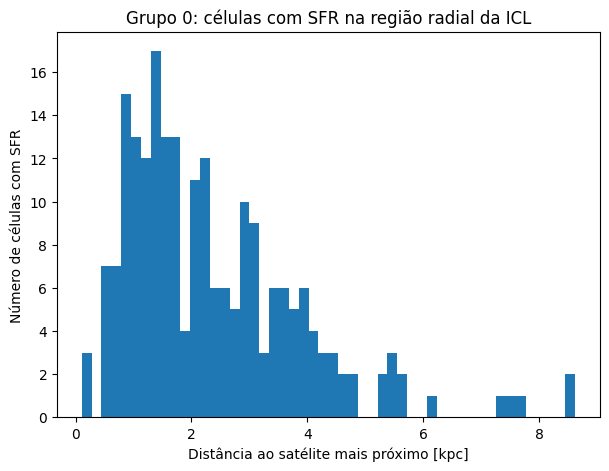

Mediana: 2.1082734118468895
Mínimo: 0.10610812307607927
Máximo: 8.613540310781994


In [6]:
res = all_results[0] # mudar entre 0, 1 e 2

plt.figure(figsize=(7,5))
plt.hist(res['dist_min'], bins=50)
plt.xlabel('Distância ao satélite mais próximo [kpc]')
plt.ylabel('Número de células com SFR')
plt.title(f"Grupo {res['group_id']}: células com SFR na região radial da ICL")
plt.savefig(f"v2_Grupo{res['group_id']}_Ahvazi_z0{zred[-1]}_plot1")
plt.show()

print("Mediana:", np.median(res['dist_min']))
print("Mínimo:", np.min(res['dist_min']))
print("Máximo:", np.max(res['dist_min']))

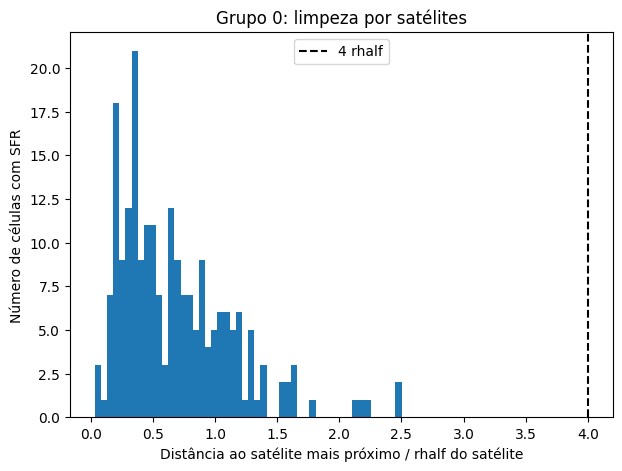

In [7]:
x = res['dist_min'] / res['rhalf_nearest']

plt.figure(figsize=(7,5))
plt.hist(x, bins=50)
plt.axvline(4, linestyle='--', color='k', label='4 rhalf')
plt.xlabel('Distância ao satélite mais próximo / rhalf do satélite')
plt.ylabel('Número de células com SFR')
plt.title(f"Grupo {res['group_id']}: limpeza por satélites")
plt.savefig(f"v2_Grupo{res['group_id']}_Ahvazi_z0{zred[-1]}_plot10")
plt.legend()
plt.show()

In [8]:
# TABELA RESUMO

print("\nResumo:")
print("GroupID | M200 [Msun] | R200 [kpc] | M_BCG [Msun] | M_ICL [Msun] | f_ICL | SFR_ICL")

for res in all_results:
    print(f"{res['group_id']:7d} | {res['M200']:.2e} | {res['R200']:.1f} | {res['M_BCG']:.2e} | {res['M_ICL']:.2e} | {res['f_ICL']:.3f} | {res['SFR_ICL']:.3e}")


Resumo:
GroupID | M200 [Msun] | R200 [kpc] | M_BCG [Msun] | M_ICL [Msun] | f_ICL | SFR_ICL
      0 | 1.81e+14 | 1192.9 | 1.45e+12 | 5.78e+11 | 0.398 | 0.000e+00
      1 | 9.20e+13 | 951.9 | 3.78e+11 | 2.42e+11 | 0.640 | 1.604e+00
      2 | 6.43e+13 | 844.9 | 4.14e+11 | 2.01e+11 | 0.486 | 5.964e-01


In [9]:
from matplotlib.colors import LogNorm

def plot_sfr_map(res, bins=300):

    gas_pos = res['gas_pos']
    gas_sfr = res['gas_sfr']
    is_gas_icl = res['is_gas_icl']

    x = gas_pos[is_gas_icl, 0]
    y = gas_pos[is_gas_icl, 1]
    sfr = gas_sfr[is_gas_icl]

    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(sfr) & (sfr > 0)

    x = x[valid]
    y = y[valid]
    sfr = sfr[valid]

    print("Número de células no mapa:", len(sfr))
    print("SFR total no mapa:", np.sum(sfr))

    if len(sfr) == 0:
        print("Não há células com SFR > 0 após a limpeza. O mapa não será feito.")
        return

    plt.figure(figsize=(7, 6))

    h = plt.hist2d(x, y, bins=bins, weights=sfr, norm=LogNorm())

    plt.colorbar(h[3], label='SFR [Msun/yr por bin]')

    plt.xlabel('x [kpc]')
    plt.ylabel('y [kpc]')
    plt.title(f"Mapa de SFR da ICL - Grupo {res['group_id']}")
    plt.axis('equal')
    plt.savefig(f"v2_Grupo{res['group_id']}_Ahvazi_z0{zred[-1]}_plot2")
    plt.show()

In [10]:
res = all_results[0]
plot_sfr_map(res)

Número de células no mapa: 0
SFR total no mapa: 0.0
Não há células com SFR > 0 após a limpeza. O mapa não será feito.


In [11]:
print("SFR radial:", res['SFR_ICL_radial'])
print("SFR difusa:", res['SFR_ICL_diffuse'])
print("Fração difusa:", res['frac_diffuse'])

print("Células radiais:", len(res['gas_sfr_icl']))
print("Células difusas:", np.sum(res['diffuse_mask']))
print("Células removidas:", np.sum(~res['diffuse_mask']))

SFR radial: 0.5835408
SFR difusa: 0.0
Fração difusa: 0.0
Células radiais: 216
Células difusas: 0
Células removidas: 216


In [12]:
sfr_icl = res['gas_sfr'][res['is_gas_icl']]

print("Número de células de gás na ICL com SFR:", len(sfr_icl))
print("SFR total:", np.sum(sfr_icl))

if len(sfr_icl) > 0:
    print("SFR mínima:", np.min(sfr_icl))
    print("SFR máxima:", np.max(sfr_icl))
else:
    print("SFR mínima: não definida, pois não há células após a limpeza")
    print("SFR máxima: não definida, pois não há células após a limpeza")

Número de células de gás na ICL com SFR: 0
SFR total: 0.0
SFR mínima: não definida, pois não há células após a limpeza
SFR máxima: não definida, pois não há células após a limpeza


In [13]:
print("ANTES da limpeza")
print("Células:", len(res['gas_sfr_icl']))
print("SFR total:", np.sum(res['gas_sfr_icl']))
print("SFR mínima:", np.min(res['gas_sfr_icl']))
print("SFR máxima:", np.max(res['gas_sfr_icl']))

print("\nDEPOIS da limpeza")
sfr_diffuse = res['gas_sfr_icl'][res['diffuse_mask']]
print("Células:", len(sfr_diffuse))
print("SFR total:", np.sum(sfr_diffuse))

if len(sfr_diffuse) > 0:
    print("SFR mínima:", np.min(sfr_diffuse))
    print("SFR máxima:", np.max(sfr_diffuse))
else:
    print("SFR mínima/máxima: não definidas")

ANTES da limpeza
Células: 216
SFR total: 0.5835408
SFR mínima: 0.0010045466
SFR máxima: 0.0063856593

DEPOIS da limpeza
Células: 0
SFR total: 0.0
SFR mínima/máxima: não definidas


In [14]:
from matplotlib.colors import LogNorm
import numpy as np
import matplotlib.pyplot as plt

def plot_sfr_map(res, bins=300):
    
    gas_pos = res['gas_pos']
    gas_sfr = res['gas_sfr']
    is_gas_icl = res['is_gas_icl']
    r200 = res['R200']
    rhalf = res['rhalf_BCG']
    
    x = gas_pos[is_gas_icl, 0]
    y = gas_pos[is_gas_icl, 1]
    sfr = gas_sfr[is_gas_icl]
    
    # remover valores problemáticos
    valid = np.isfinite(x) & np.isfinite(y) & np.isfinite(sfr) & (sfr > 0)
    x = x[valid]
    y = y[valid]
    sfr = sfr[valid]
    
    if len(sfr) == 0:
        print("Não há gás com SFR > 0 na região da ICL para este grupo.")
        return
    
    fig, ax = plt.subplots(figsize=(7, 6))
    
    h2d = ax.hist2d(x, y, bins=bins, weights=sfr, norm=LogNorm())
    
    fig.colorbar(h2d[3], ax=ax, label='SFR [Msun/yr por bin]')
    
    # Centro correto: posição da BCG, não mediana dos pontos
    central_pos = np.median(res['star_pos'][res['r_star'] < 2*rhalf], axis=0)
    cx, cy = central_pos[0], central_pos[1]
    
    circle_r200 = plt.Circle((cx, cy), r200, fill=False, linestyle='-', linewidth=2)
    
    circle_inner = plt.Circle((cx, cy), 2*rhalf, fill=False, linestyle='--', linewidth=2)
    
    ax.add_patch(circle_r200)
    ax.add_patch(circle_inner)
    
    ax.set_xlabel('x [kpc]')
    ax.set_ylabel('y [kpc]')
    ax.set_title(f"Mapa de SFR da ICL - Grupo {res['group_id']}")
    ax.set_aspect('equal')
    
    ax.set_xlim(cx - r200, cx + r200)
    ax.set_ylim(cy - r200, cy + r200)
    
    plt.savefig(f"v2_Grupo{res['group_id']}_Ahvazi_z0{zred[-1]}_plot3")
    
    plt.show()

In [15]:
plot_sfr_map(res)

Não há gás com SFR > 0 na região da ICL para este grupo.


In [16]:
mask = res['is_gas_icl']
sfr_icl = res['gas_sfr'][mask]

print("Número de células de gás na ICL com SFR:", len(sfr_icl))
print("SFR total:", np.sum(sfr_icl))

if len(sfr_icl) > 0:
    print("SFR mínima:", np.min(sfr_icl))
    print("SFR máxima:", np.max(sfr_icl))
else:
    print("Não há células de gás com SFR > 0 na ICL para este grupo.")

Número de células de gás na ICL com SFR: 0
SFR total: 0.0
Não há células de gás com SFR > 0 na ICL para este grupo.


In [17]:
gas_sfr = res['gas_sfr']
r_gas = res['r_gas']
rhalf = res['rhalf_BCG']
r200 = res['R200']

inner = 2 * rhalf

print("Total de células de gás:", len(gas_sfr))
print("Células com SFR > 0 no halo:", np.sum(gas_sfr > 0))
print("SFR total do halo:", np.sum(gas_sfr))

print("Células entre 2rh e R200:", np.sum((r_gas >= inner) & (r_gas <= r200)))
print("Células com SFR > 0 entre 2rh e R200:", np.sum((r_gas >= inner) & (r_gas <= r200) & (gas_sfr > 0)))

print("SFR entre 2rh e R200:", np.sum(gas_sfr[(r_gas >= inner) & (r_gas <= r200)]))

Total de células de gás: 4847596
Células com SFR > 0 no halo: 1132
SFR total do halo: 5.4909115
Células entre 2rh e R200: 4074207
Células com SFR > 0 entre 2rh e R200: 216
SFR entre 2rh e R200: 0.5835408


In [18]:
def plot_sfr_map_radial_only(res, bins=300):
    
    gas_pos = res['gas_pos']
    gas_sfr = res['gas_sfr']
    r_gas = res['r_gas']
    r200 = res['R200']
    rhalf = res['rhalf_BCG']
    
    inner = 2 * rhalf
    
    mask = (r_gas >= inner) & (r_gas <= r200) & (gas_sfr > 0)
    
    print("Células no mapa:", np.sum(mask))
    print("SFR total no mapa:", np.sum(gas_sfr[mask]))
    
    if np.sum(mask) == 0:
        print("Ainda não há gás com SFR > 0 entre 2rh e R200.")
        return
    
    x = gas_pos[mask, 0]
    y = gas_pos[mask, 1]
    sfr = gas_sfr[mask]
    
    fig, ax = plt.subplots(figsize=(7, 6))
    
    h2d = ax.hist2d(x, y, bins=bins, weights=sfr)
    
    fig.colorbar(h2d[3], ax=ax, label='SFR [Msun/yr por bin]')
    
    ax.set_xlabel('x [kpc]')
    ax.set_ylabel('y [kpc]')
    ax.set_title(f"SFR entre 2rh e R200 - Grupo {res['group_id']}")
    ax.set_aspect('equal')
    
    plt.savefig(f"v2_Grupo{res['group_id']}_Ahvazi_z0{zred[-1]}_plot4")
    
    plt.show()

Células no mapa: 216
SFR total no mapa: 0.5835408


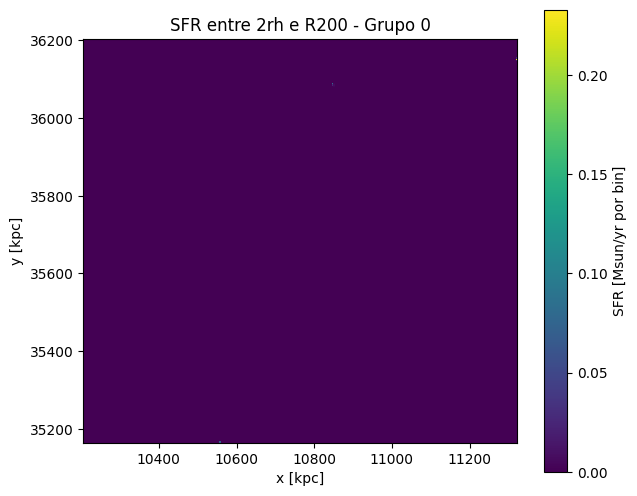

In [19]:
plot_sfr_map_radial_only(res)

Células no mapa: 216
SFR total no mapa: 0.5835408


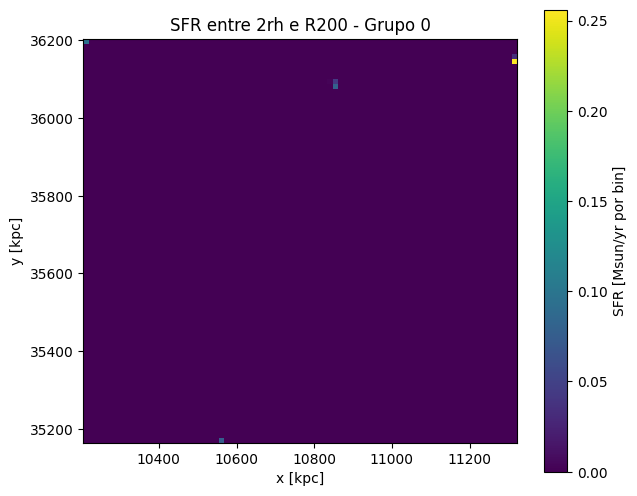

In [20]:
plot_sfr_map_radial_only(res, bins=80)

In [21]:
def plot_sfr_scatter_radial_only(res):
    gas_pos = res['gas_pos']
    gas_sfr = res['gas_sfr']
    r_gas = res['r_gas']
    r200 = res['R200']
    rhalf = res['rhalf_BCG']
    
    inner = 2 * rhalf
    mask = (r_gas >= inner) & (r_gas <= r200) & (gas_sfr > 0)
    
    print("Células com SFR:", np.sum(mask))
    print("SFR total:", np.sum(gas_sfr[mask]))
    
    if np.sum(mask) == 0:
        return
    
    x = gas_pos[mask, 0]
    y = gas_pos[mask, 1]
    sfr = gas_sfr[mask]
    
    plt.figure(figsize=(7, 6))
    plt.scatter(x, y, c=np.log10(sfr), s=20)
    plt.colorbar(label='log10 SFR [Msun/yr]')
    plt.xlabel('x [kpc]')
    plt.ylabel('y [kpc]')
    plt.title(f'Células de gás formando estrelas - Grupo {res["group_id"]}')
    plt.axis('equal')
    plt.savefig(f"v2_Grupo{res['group_id']}_Ahvazi_z0{zred[-1]}_plot5")
    plt.show()

Células com SFR: 216
SFR total: 0.5835408


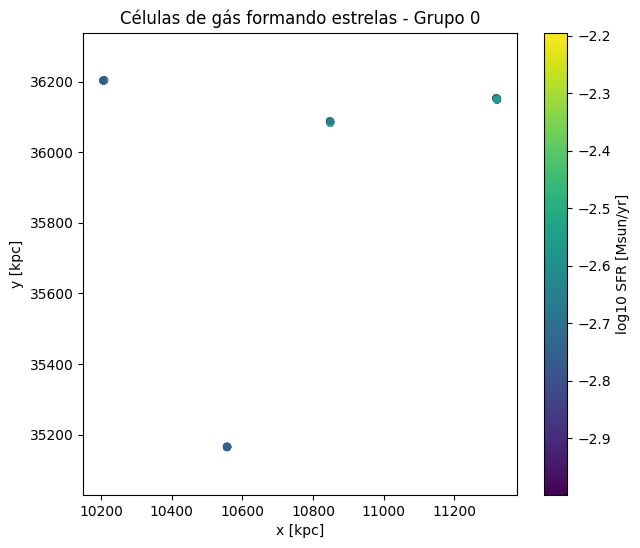

In [22]:
plot_sfr_scatter_radial_only(res)

In [23]:
#for i, res in enumerate(all_results):
#    print("\nGrupo:", i, "FoF:", res["group_id"])
#    plot_sfr_scatter_radial_only(res)

In [24]:
# Teste 1: Existe gás formador de estrelas no halo?

for i, res in enumerate(all_results):

    gas_sfr = res['gas_sfr']

    print("\nGrupo", i)
    print("Total células:", len(gas_sfr))
    print("Células com SFR > 0:", np.sum(gas_sfr > 0))
    print("SFR total:", np.sum(gas_sfr))
    
# Se aparecer um número razoável de células com SFR>0, então o gás está formando estrelas, mas não na ICL.


Grupo 0
Total células: 4847596
Células com SFR > 0: 1132
SFR total: 5.4909115

Grupo 1
Total células: 2271997
Células com SFR > 0: 4875
SFR total: 15.240649

Grupo 2
Total células: 1698291
Células com SFR > 0: 1965
SFR total: 5.9611073


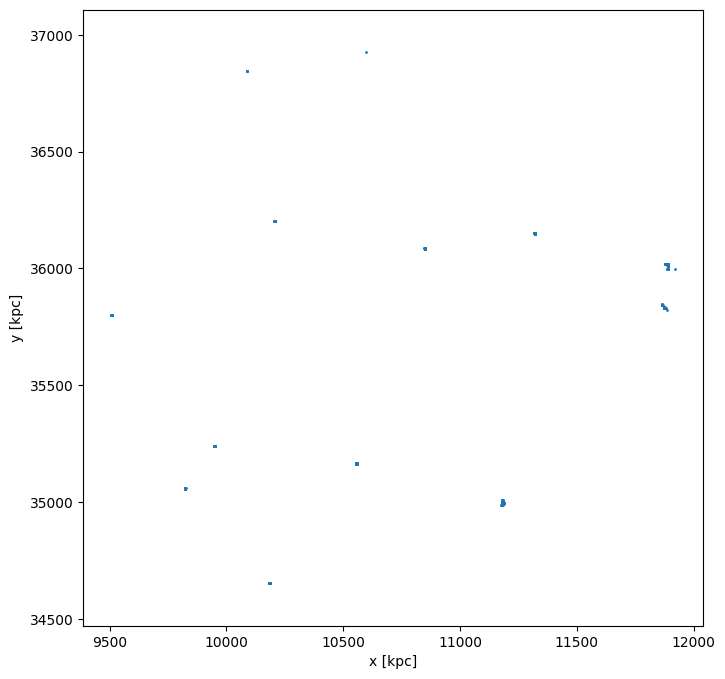

In [25]:
# Teste 2: Onde está esse gás?

res = all_results[0]

mask = res['gas_sfr'] > 0

plt.figure(figsize=(8,8))
plt.scatter(res['gas_pos'][mask,0], res['gas_pos'][mask,1], s=1)

plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')
plt.axis('equal')
plt.savefig(f"v2_Grupo{res['group_id']}_Ahvazi_z0{zred[-1]}_plot6")
plt.show()

# Se tudo estiver concentrado no centro, então o TNG50-3 não está produzindo formação estelar difusa.

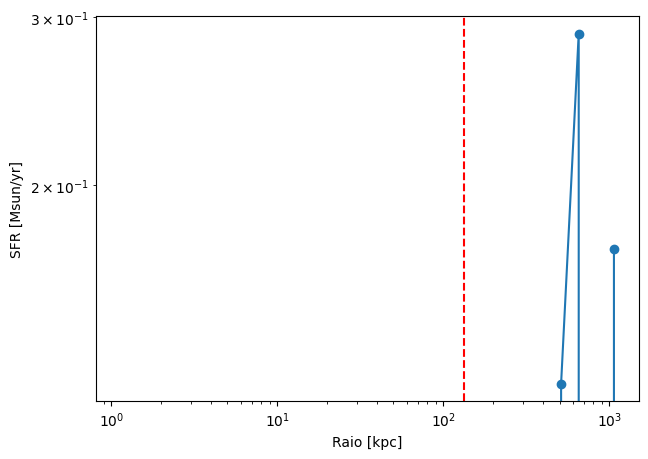

In [26]:
# Teste 3: Verificar o perfil radial da SFR

r = res['r_gas']
sfr = res['gas_sfr']

bins = np.logspace(np.log10(1), np.log10(res['R200']), 30)

sfr_bin = []

for rmin, rmax in zip(bins[:-1], bins[1:]):

    mask = (r >= rmin) & (r < rmax)

    sfr_bin.append(np.sum(sfr[mask]))

plt.figure(figsize=(7,5))

plt.loglog(0.5*(bins[:-1]+bins[1:]), sfr_bin, marker='o')

plt.axvline(2*res['rhalf_BCG'], ls='--', c='r')

plt.xlabel('Raio [kpc]')
plt.ylabel('SFR [Msun/yr]')
plt.savefig(f"v2_Grupo{res['group_id']}_Ahvazi_z0{zred[-1]}_plot")
plt.show()

In [27]:
# teste onde esses pontos estão em relação a 2rh, R200 e aos satélites:

for i, res in enumerate(all_results):
    mask = res['gas_sfr'] > 0
    
    print("\nGrupo", i, "FoF:", res["group_id"])
    print("Células com SFR > 0:", np.sum(mask))
    print("SFR total:", np.sum(res['gas_sfr'][mask]))
    
    r = res['r_gas'][mask]
    
    print("Raio mínimo:", np.min(r))
    print("Raio mediano:", np.median(r))
    print("Raio máximo:", np.max(r))
    print("2 rhalf:", 2 * res['rhalf_BCG'])
    print("R200:", res['R200'])
    
    print("Células com SFR fora da BCG:", np.sum(mask & (res['r_gas'] > 2 * res['rhalf_BCG'])))
    
    print("Células com SFR na região radial da ICL:", np.sum(mask & (res['r_gas'] > 2 * res['rhalf_BCG']) & (res['r_gas'] < res['R200'])))


Grupo 0 FoF: 0
Células com SFR > 0: 1132
SFR total: 5.4909115
Raio mínimo: 500.55875873256275
Raio mediano: 1316.9034893587518
Raio máximo: 2052.753512977083
2 rhalf: 133.185396512631
R200: 1192.9471759553994
Células com SFR fora da BCG: 1132
Células com SFR na região radial da ICL: 216

Grupo 1 FoF: 1
Células com SFR > 0: 4875
SFR total: 15.240649
Raio mínimo: 40.242387603931995
Raio mediano: 398.94424231327446
Raio máximo: 1398.8204162245702
2 rhalf: 57.68328526747202
R200: 951.9323726864666
Células com SFR fora da BCG: 4857
Células com SFR na região radial da ICL: 4831

Grupo 2 FoF: 2
Células com SFR > 0: 1965
SFR total: 5.9611073
Raio mínimo: 28.253729113968824
Raio mediano: 725.1647991331723
Raio máximo: 1886.4672838801541
2 rhalf: 62.491662177780505
R200: 844.9195611783105
Células com SFR fora da BCG: 1555
Células com SFR na região radial da ICL: 976


In [28]:
# Se aparecerem células na região radial da ICL, mas is_gas_icl continuar zero, então a limpeza por satélite está removendo tudo. 
# Nesse caso, para diagnóstico, use três categorias:

def classify_sfr_regions(res):
    sfr = res['gas_sfr']
    r = res['r_gas']
    inner = 2 * res['rhalf_BCG']
    r200 = res['R200']
    
    sf = sfr > 0
    
    in_bcg = sf & (r <= inner)
    in_icl_radial = sf & (r > inner) & (r <= r200)
    outside_r200 = sf & (r > r200)
    
    print("\nSFR BCG:", np.sum(sfr[in_bcg]))
    print("SFR região radial ICL:", np.sum(sfr[in_icl_radial]))
    print("SFR fora de R200:", np.sum(sfr[outside_r200]))
    
    print("N células BCG:", np.sum(in_bcg))
    print("N células radial ICL:", np.sum(in_icl_radial))
    print("N células fora R200:", np.sum(outside_r200))

for res in all_results:
    classify_sfr_regions(res)


SFR BCG: 0.0
SFR região radial ICL: 0.5835408
SFR fora de R200: 4.90737
N células BCG: 0
N células radial ICL: 216
N células fora R200: 916

SFR BCG: 0.042416874
SFR região radial ICL: 15.134151
SFR fora de R200: 0.06408036
N células BCG: 18
N células radial ICL: 4831
N células fora R200: 26

SFR BCG: 1.1461431
SFR região radial ICL: 2.8031483
SFR fora de R200: 2.011816
N células BCG: 410
N células radial ICL: 976
N células fora R200: 579


In [29]:
res = all_results[0]

radial = ((res['r_gas'] >= 2*res['rhalf_BCG']) & (res['r_gas'] <= res['R200']) & (res['gas_sfr'] > 0))

print("Antes da limpeza:")
print(np.sum(radial))

print("Depois da limpeza:")
print(np.sum(res['is_gas_icl']))

Antes da limpeza:
216
Depois da limpeza:
0


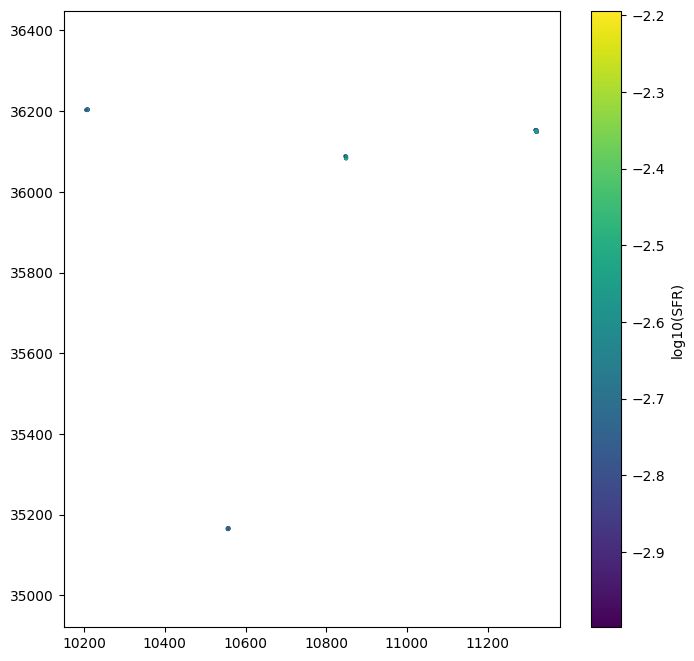

In [30]:
# Agora precisamos descobrir se essa SFR é realmente difusa ou se está concentrada em poucos objetos

mask = ((res['r_gas'] >= 2*res['rhalf_BCG']) & (res['r_gas'] <= res['R200']) & (res['gas_sfr'] > 0))

plt.figure(figsize=(8,8))

plt.scatter(res['gas_pos'][mask,0], res['gas_pos'][mask,1], c=np.log10(res['gas_sfr'][mask]), s=3)

plt.colorbar(label='log10(SFR)')
plt.axis('equal')
plt.savefig(f"v2_Grupo{res['group_id']}_Ahvazi_z0{zred[-1]}_plot8")
plt.show()

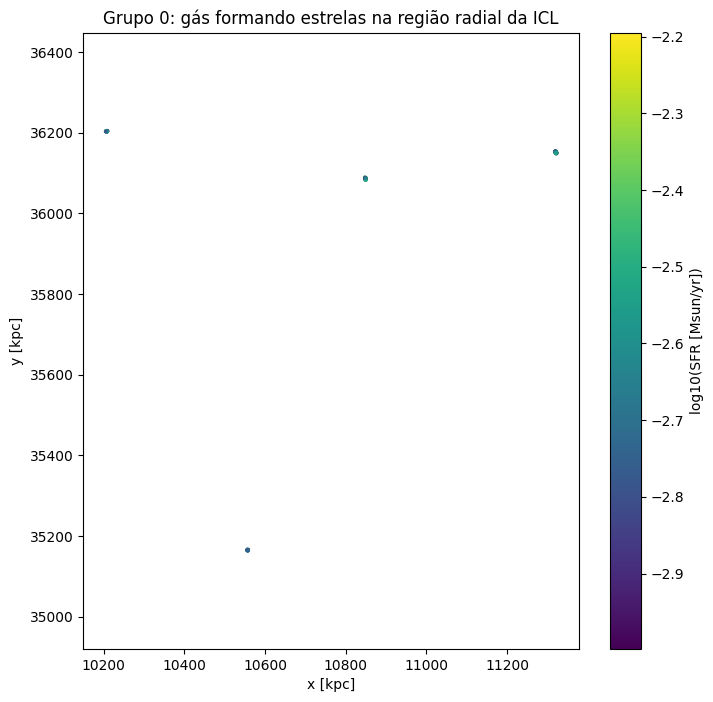

In [31]:
# Próximo passo: faça o mapa do Grupo

mask = ((res['r_gas'] >= 2*res['rhalf_BCG']) & (res['r_gas'] <= res['R200']) & (res['gas_sfr'] > 0))

plt.figure(figsize=(8,8))

plt.scatter(res['gas_pos'][mask,0], res['gas_pos'][mask,1], c=np.log10(res['gas_sfr'][mask]), s=3)

plt.colorbar(label='log10(SFR [Msun/yr])')
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')
plt.title(f"Grupo {res['group_id']}: gás formando estrelas na região radial da ICL")
plt.axis('equal')
plt.savefig(f"v2_Grupo{res['group_id']}_Ahvazi_z0{zred[-1]}_plot9")
plt.show()